# Exercise 10.1b solution


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt


def transition_matrix(k_co, k_oc, k_oi, k_io):
    """Build the 3x3 transition rate matrix for the C-O-I model."""
    # State indices
    C = 0
    O = 1
    I = 2

    n = 3
    A = np.zeros((n, n))

    # Off-diagonal transition rates
    # A[to_state, from_state] = rate
    A[O, C] = k_co  # C -> O
    A[C, O] = k_oc  # O -> C
    A[I, O] = k_oi  # O -> I
    A[O, I] = k_io  # I -> O

    # Diagonal: each column sums to zero
    for i in range(n):
        A[i, i] = -np.sum(A[:, i]) + A[i, i]

    return A


# Set rate constants
k_co = 5
k_oc = 10
k_oi = 1
k_io = 0

A = transition_matrix(k_co, k_oc, k_oi, k_io)
# ----------------------------------------------

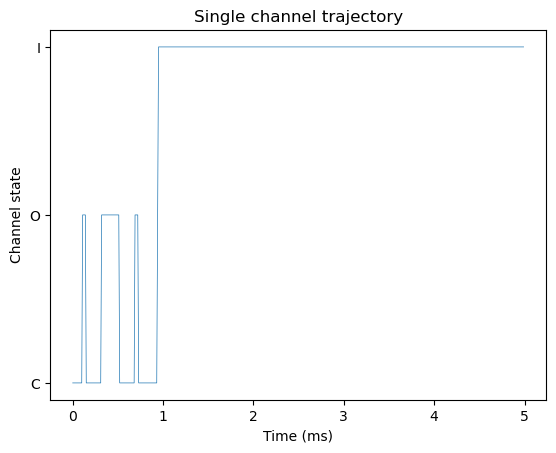

In [2]:
def advance_stochastic(state, A, dt):
    """Advance a single channel by one time step using stochastic simulation.

    Parameters
    ----------
    state : int
        Current state index (0=C, 1=O, 2=I)
    A : ndarray
        Transition rate matrix
    dt : float
        Time step

    Returns
    -------
    int
        New state index
    """

    # Get transition probabilities from current state
    P = A[:, state] * dt

    P[state] = 0  # No self-transition

    # Use cumulative probability to decide transition
    CP = np.cumsum(P)
    r = np.random.rand()
    for i in range(len(CP)):
        if r < CP[i]:
            state = i
            return i

    return state  # No transition


# Simulate a single channel
dt = 0.01
t = np.arange(0, 5, dt)
s = np.zeros(len(t), dtype=int)
s[0] = 0

for i in range(len(t) - 1):
    s[i + 1] = advance_stochastic(s[i], A, dt)

plt.plot(t, s, linewidth=0.5)
plt.yticks([0, 1, 2], ["C", "O", "I"])
plt.xlabel("Time (ms)")
plt.ylabel("Channel state")
plt.title("Single channel trajectory")
plt.show()

**Answers:**

1. Each run gives a different trajectory because the simulation is stochastic — the random number generator produces different sequences each time.

2. With $k_{IO} = 0$, the channel can never leave the inactivated state once it enters it. This is not physically realistic — real channels do recover from inactivation. Setting $k_{IO} > 0$ (e.g., $k_{IO} = 0.5$) would allow recovery.
